In [67]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

def fetch_data(ticker, start_date, end_date):
    """Fetch stock data from Yahoo Finance."""
    data = yf.download(ticker, start=start_date, end=end_date)
    return data

def calculate_indicators(data):
    """Calculate various technical indicators."""
    # set the ticker value of each column to the ticker value of the data
    data['MA50'] = data['Close'].rolling(window=50).mean()
    
    data['MA200'] = data['Close'].rolling(window=200).mean()
    data['RSI'] = calculate_rsi(data['Close'])
    data['Upper_BB'], data['Lower_BB'] = calculate_bollinger_bands(data['Close'])
    data['MACD'], data['Signal'] = calculate_macd(data['Close'])
    data['Stochastic'] = calculate_stochastic(data)
    return data

def calculate_rsi(close, period=14):
    """Calculate the Relative Strength Index."""
    delta = close.diff()
    gain = np.where(delta > 0, delta, 0).ravel()
    loss = np.where(delta < 0, -delta, 0).ravel()
    
    avg_gain = pd.Series(gain, index=close.index).rolling(window=period).mean()
    avg_loss = pd.Series(loss, index=close.index).rolling(window=period).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi


def calculate_bollinger_bands(close, period=20):
    """Calculate Bollinger Bands."""
    sma = close.rolling(window=period).mean()
    std = close.rolling(window=period).std()
    upper_band = sma + (2 * std)
    lower_band = sma - (2 * std)
    return upper_band, lower_band

def calculate_macd(close, fast=12, slow=26, signal=9):
    """Calculate MACD and Signal Line."""
    fast_ema = close.ewm(span=fast, adjust=False).mean()
    slow_ema = close.ewm(span=slow, adjust=False).mean()
    macd = fast_ema - slow_ema
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

def calculate_stochastic(data, period=14):
    """Calculate Stochastic Oscillator."""
    low_14 = data['Low'].rolling(window=period).min()
    high_14 = data['High'].rolling(window=period).max()
    stoch = 100 * (data['Close'] - low_14) / (high_14 - low_14)
    return stoch

def generate_signal(data):
    """Generate buy/sell signal based on indicators."""
    # drop rows with null values
    data.dropna(inplace=True)

    # Initialize Signal column
    data['Signal'] = 0

    # Generate signals based on conditions
    data.loc[(data['Close'].values.flatten() > data['Upper_BB'].values.flatten()) & (data['RSI'] > 70), 'Signal'] = -1  # Sell
    data.loc[(data['Close'].values.flatten() < data['Lower_BB'].values.flatten()) & (data['RSI'] < 30), 'Signal'] = 1   # Buy

    # Moving average crossover signals
    data.loc[data['MA50'] > data['MA200'], 'Signal'] += 1  # Add to buy signal
    data.loc[data['MA50'] < data['MA200'], 'Signal'] -= 1  # Add to sell signal

    return data

def plot_data(data):
    """Plot stock data with indicators."""
    # graph close and have green color when signal is 1 and red when signal is -1

    plt.figure(figsize=(14, 7))
    plt.plot(data['Close'], label='Close Price', alpha=0.7)
    plt.plot(data['MA50'], label='50-day MA', linestyle='--')
    plt.plot(data['MA200'], label='200-day MA', linestyle='--')
    plt.fill_between(data.index, data['Upper_BB'], data['Lower_BB'], color='gray', alpha=0.2, label='Bollinger Bands')
    plt.scatter(data.index, data['Close'], c=data['Signal'], cmap='Accent_r', lw=0)
    plt.legend()
    plt.title('Stock Price with Indicators')
    plt.show()


In [68]:
ticker = 'AAPL'  # Replace with your desired stock ticker
start_date = '2000-01-01'
end_date = '2023-12-31'

data = fetch_data(ticker, start_date, end_date)
data = calculate_indicators(data)
data = generate_signal(data)


[*********************100%***********************]  1 of 1 completed


In [69]:
data.head(20)

Price,Close,High,Low,Open,Volume,MA50,MA200,RSI,Upper_BB,Lower_BB,MACD,Signal,Stochastic
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,
Date,,,,,,,,,,,,,
2000-10-16,0.323862,0.350223,0.321979,0.336101,820176000,0.706047,0.798144,18.023972,1.029182,0.030124,-0.137622,-1,6.846876
2000-10-17,0.303150,0.330452,0.296560,0.326686,601720000,0.697668,0.795445,18.467787,0.976345,0.022990,-0.134537,-1,2.882860
2000-10-18,0.303150,0.317272,0.282437,0.292794,834265600,0.689647,0.793100,9.422447,0.909565,0.028129,-0.130587,-1,13.414852
2000-10-19,0.285262,0.298443,0.275847,0.288557,1506724800,0.681042,0.790610,26.609428,0.848715,0.032114,-0.127431,-1,7.407574
2000-10-20,0.293735,0.306915,0.285262,0.287145,791263200,0.672588,0.788501,32.568578,0.794645,0.036946,-0.122830,-1,17.756668
2000-10-23,0.306915,0.309740,0.292794,0.305268,551292000,0.664359,0.786289,42.288325,0.724561,0.057132,-0.116774,-1,33.333039
2000-10-24,0.284321,0.314447,0.283379,0.311623,804451200,0.655867,0.784029,31.372498,0.649487,0.083156,-0.112501,-1,9.091229
2000-10-25,0.278672,0.289028,0.277730,0.287145,663969600,0.647375,0.781930,34.594523,0.568419,0.118375,-0.108322,-1,3.797325


In [70]:
# show na values of data
data.loc[data['Close'].values.flatten() > data['Upper_BB'].values.flatten(), 'Signal'] = -1  # Sell
data.head()

Price,Close,High,Low,Open,Volume,MA50,MA200,RSI,Upper_BB,Lower_BB,MACD,Signal,Stochastic
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,
Date,,,,,,,,,,,,,
2000-10-16,0.323862,0.350223,0.321979,0.336101,820176000,0.706047,0.798144,18.023972,1.029182,0.030124,-0.137622,-1,6.846876
2000-10-17,0.303150,0.330452,0.296560,0.326686,601720000,0.697668,0.795445,18.467787,0.976345,0.022990,-0.134537,-1,2.882860
2000-10-18,0.303150,0.317272,0.282437,0.292794,834265600,0.689647,0.793100,9.422447,0.909565,0.028129,-0.130587,-1,13.414852
2000-10-19,0.285262,0.298443,0.275847,0.288557,1506724800,0.681042,0.790610,26.609428,0.848715,0.032114,-0.127431,-1,7.407574
2000-10-20,0.293735,0.306915,0.285262,0.287145,791263200,0.672588,0.788501,32.568578,0.794645,0.036946,-0.122830,-1,17.756668


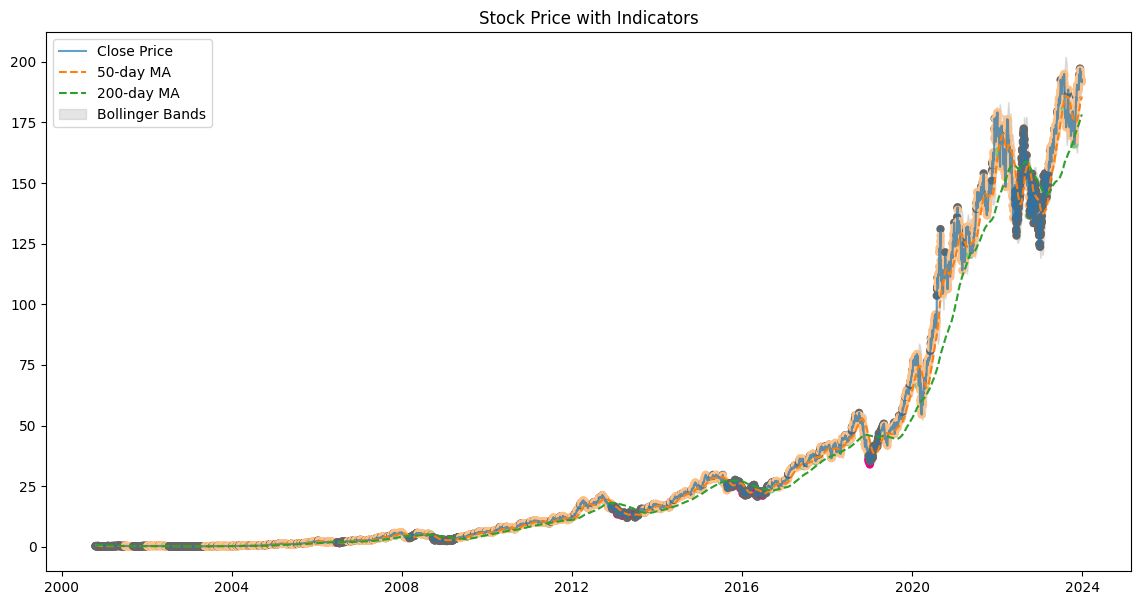

In [71]:
plot_data(data)

In [72]:

def backtest(data):
    """Backtest signals and calculate returns."""
    data['Strategy_Returns'] = data['Signal'].shift(1).values.flatten() * data['Close'].pct_change().values.flatten()
    cumulative_returns = (1 + data['Strategy_Returns']).cumprod()
    return cumulative_returns

In [73]:
data['Signal'].shift(1).describe()

count    5837.000000
mean        0.404317
std         0.934068
min        -1.000000
25%        -1.000000
50%         1.000000
75%         1.000000
max         2.000000
Name: Signal, dtype: float64

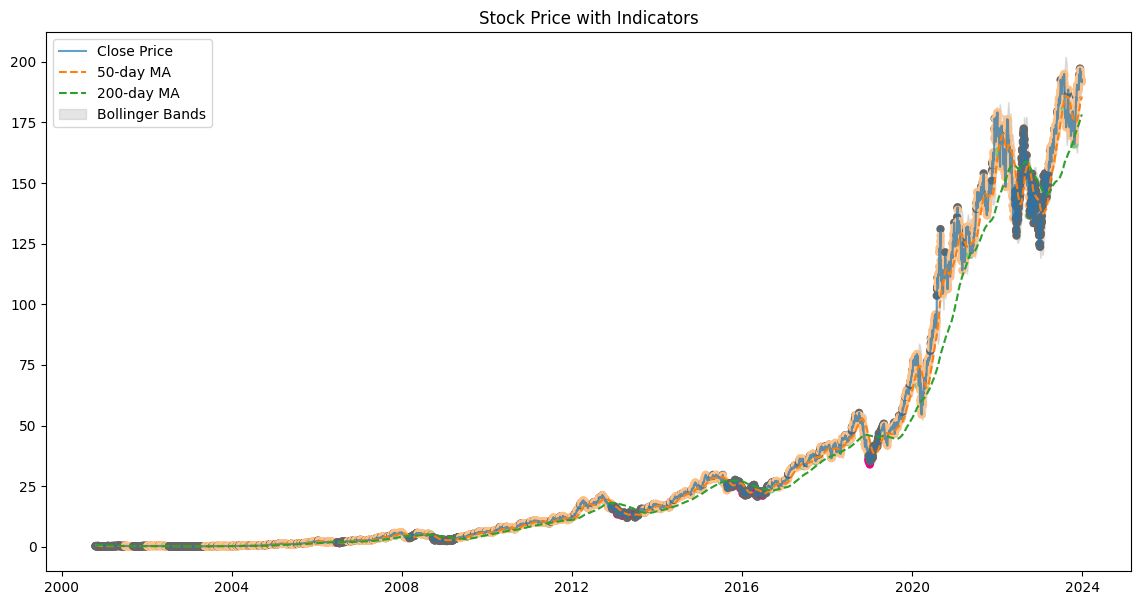

Cumulative Returns: 3.4362564386074856


In [74]:

cumulative_returns = backtest(data)

plot_data(data)
print("Cumulative Returns:", cumulative_returns.iloc[-1])